In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/job_salary_prediction_dataset.csv")

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")



 dataframe head :             job_title  experience_years education_level  skills_count  \
0         AI Engineer                10        Bachelor             2   
1        Data Analyst                 5        Bachelor            17   
2  Frontend Developer                18             PhD             4   
3    Business Analyst                19             PhD            13   
4     Product Manager                15        Bachelor             7   

        industry company_size   location remote_work  certifications  salary  
0     Healthcare       Medium      India      Hybrid               2  109413  
1        Telecom        Small  Australia          No               0   93764  
2          Media       Medium  Singapore          No               1  148123  
3         Retail       Medium     Canada         Yes               0  189123  
4  Manufacturing        Large     Sweden         Yes               0  165069  
 dataframe shape : (250000, 10)
<class 'pandas.core.frame.DataFrame'>

In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer # Import SimpleImputer

df = pd.read_csv("/content/job_salary_prediction_dataset.csv")

y = df['salary']
x = df.drop(['salary'], axis = 1)

imputer = SimpleImputer(strategy='most_frequent')
x = pd.DataFrame(imputer.fit_transform(x), columns=x.columns)

for col in x.columns:
  if x[col].dtype == 'object':
    x[col] = LabelEncoder().fit_transform(x[col])
  else:
    x[col] = StandardScaler().fit_transform(x[col].values.reshape(-1, 1))

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(200000, 9)
(50000, 9)
(200000,)
(50000,)


Mean Squared Error: 27689610.00
R-squared: 0.98


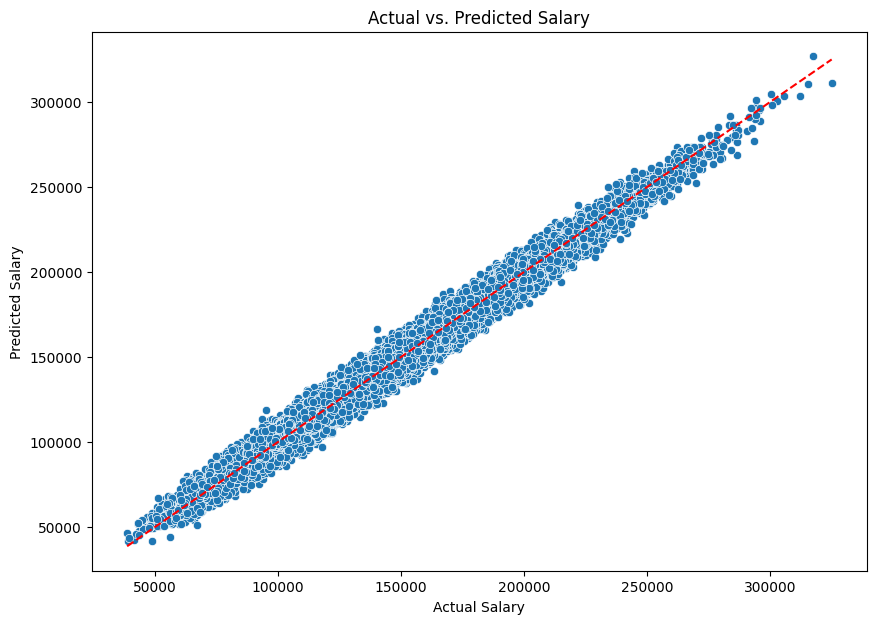

In [71]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize XGBoost Regressor model
xgb_regressor = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1
)

# Train the model
xgb_regressor.fit(x_train, y_train)

# Make predictions on the test set
y_pred = xgb_regressor.predict(x_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

# Plotting actual vs. predicted values
plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs. Predicted Salary")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--') # Ideal line
plt.show()

In [72]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 
